In [248]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Read in housing data
housing =  pd.read_excel("ames_housing_data.xlsx")

#Look at housing data
housing.head()

,SID,PID,SubClass,Zoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [249]:
#Non-null count and data types
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SID            2930 non-null   int64  
 1   PID            2930 non-null   int64  
 2   SubClass       2930 non-null   int64  
 3   Zoning         2930 non-null   object 
 4   LotFrontage    2440 non-null   float64
 5   LotArea        2930 non-null   int64  
 6   Street         2930 non-null   object 
 7   Alley          198 non-null    object 
 8   LotShape       2930 non-null   object 
 9   LandContour    2930 non-null   object 
 10  Utilities      2930 non-null   object 
 11  LotConfig      2930 non-null   object 
 12  LandSlope      2930 non-null   object 
 13  Neighborhood   2930 non-null   object 
 14  Condition1     2930 non-null   object 
 15  Condition2     2930 non-null   object 
 16  BldgType       2930 non-null   object 
 17  HouseStyle     2930 non-null   object 
 18  OverallQ

In [250]:
# Derived variables
housing['TotalFloorSF'] = housing['FirstFlrSF'] + housing['SecondFlrSF']
housing['HouseAge'] = housing['YrSold'] - housing['YearBuilt']
housing['QualityIndex'] = housing['OverallQual'] * housing['OverallCond']

In [251]:
#Look at descriptive statistics
housing.describe()

,SID,PID,SubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodel,MasVnrArea,...,ThreeSsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,TotalFloorSF,HouseAge,QualityIndex
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068,1495.013652,36.434130,33.758020
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357,503.130162,30.291357,9.181182
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000,334.000000,-1.000000,1.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000,1120.000000,7.000000,30.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000,1440.000000,34.000000,35.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000,1740.000000,54.000000,40.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000,5642.000000,136.000000,90.000000


In [252]:
housing.shape

(2930, 85)

In [253]:
#Looking at building types for drop condition
housing["BldgType"].value_counts()

BldgType
1Fam      2425
TwnhsE     233
Duplex     109
Twnhs      101
2fmCon      62
Name: count, dtype: int64

In [254]:
#Looking at sale condition for drop condition
#Want normal 
housing["SaleCondition"].value_counts()

SaleCondition
Normal     2413
Partial     245
Abnorml     190
Family       46
Alloca       24
AdjLand      12
Name: count, dtype: int64

In [255]:
# Waterfall tracking
waterfall = []

def apply_drop(data, condition, reason):
    before = data.shape[0]
    data = data.loc[condition].copy()
    after = data.shape[0]
    waterfall.append({
        "Step": reason,
        "Remaining Observations": after,
        "Dropped": before - after
    })
    return data

# Start with full dataset
df_sample = housing.copy()


# 2. Keep only single-family residences
df_sample = apply_drop(
    df_sample,
    df_sample["BldgType"] == "1Fam",
    "Keep single-family residences only"
)

# 3. Remove extreme price outliers (top 1%)
#price_cutoff = df_sample["SalePrice"].quantile(0.99)
#df_sample = apply_drop(
#    df_sample,
#    df_sample["SalePrice"] <= price_cutoff,
#    "Remove top 1% SalePrice outliers"
#)

# Create waterfall table
waterfall_df = pd.DataFrame(waterfall)
waterfall_df

,Step,Remaining Observations,Dropped
0,Keep single-family residences only,2425,505


In [256]:
df_sample.shape

(2425, 85)

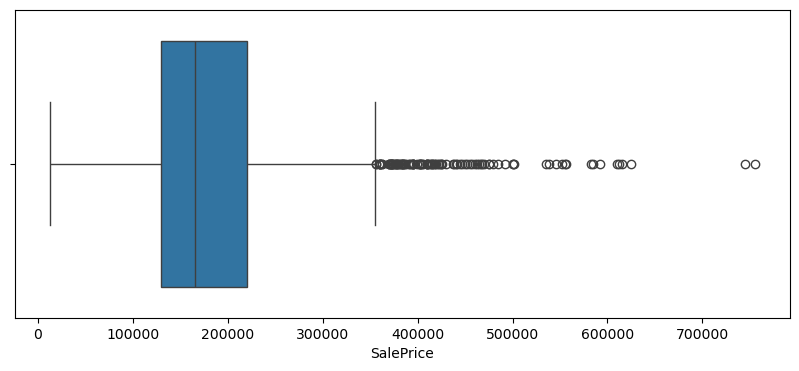

In [257]:
plt.figure(figsize = (10, 4))
sns.boxplot(x = df_sample["SalePrice"])
plt.show()

In [258]:
#Remove top %1 SalePrice of outliers
price_cutoff = df_sample["SalePrice"].quantile(0.99)
df_sample = apply_drop(
   df_sample,
   df_sample["SalePrice"] <= price_cutoff,
    "Remove top 1% SalePrice outliers"
)

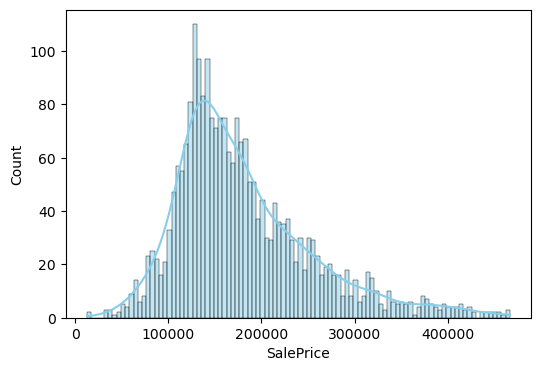

In [259]:
plt.figure(figsize=(6,4))
sns.histplot(x = df_sample["SalePrice"], bins = 100, color = "skyblue", edgecolor = "black", kde = True)
plt.show()

In [260]:
df_sample.shape

(2400, 85)

| Variable Name   | Variable Type |
|-----------------|---------------|
| SalePrice       | Numerical     |
| GrLivArea       | Numerical     |
| LotArea         | Numerical     |
| TotalFloorSF    | Numerical     |
| HouseAge        | Numerical     |
| OverallQual     | Numerical (Ordinal) |
| OverallCond     | Numerical (Ordinal) |
| BsmtFinSF1      | Numerical     |
| BsmtFinSF2      | Numerical     |
| GarageArea      | Numerical     |
| Neighborhood    | Categorical   |
| BldgType        | Categorical   |
| HouseStyle      | Categorical   |
| GarageCars      | Categorical (Discrete) |
| LotShape        | Categorical   |
| KitchenQual     | Categorical (Ordinal) |
| SaleCondition   | Categorical   |
| FireplaceQu     | Categorical (Ordinal) |
| PoolQC          | Categorical (Ordinal) |
| ExterQual       | Categorical (Ordinal) |

In [271]:
num_vars = ['SalePrice', 'GrLivArea', 'LotArea', 'TotalFloorSF', 'HouseAge',
            'OverallQual', 'OverallCond', 'BsmtFinSF1', 'BsmtFinSF2', 'GarageArea']

cat_vars = ['Neighborhood', 'BldgType', 'HouseStyle', 'GarageCars',
            'LotShape', 'KitchenQual', 'SaleCondition', 'FireplaceQu', 
            'PoolQC', 'ExterQual']

#Numeric summary
print(df_sample[num_vars].describe().transpose().drop(['count'], axis=1))

                       mean           std      min       25%       50%  \
SalePrice     180965.775323  73741.245159  12789.0  130000.0  163990.0   
GrLivArea       1502.266361    497.315977    334.0    1124.5    1458.0   
LotArea        10848.669862   7455.562515   2500.0    8175.0    9770.0   
TotalFloorSF    1497.341809    495.738033    334.0    1119.5    1456.0   
HouseAge          38.486453     30.684377      0.0       8.0      39.0   
OverallQual        6.056273      1.384021      1.0       5.0       6.0   
OverallCond        5.641517      1.151513      1.0       5.0       5.0   
BsmtFinSF1       427.845769    438.457419      0.0       0.0     360.0   
BsmtFinSF2        52.191747    171.116831      0.0       0.0       0.0   
GarageArea       477.199250    211.501809      0.0     317.5     480.0   

                   75%       max  
SalePrice     217000.0  466500.0  
GrLivArea       1771.0    5642.0  
LotArea        11886.5  215245.0  
TotalFloorSF    1768.0    5642.0  
HouseAge  

In [263]:
#Check missing values
print(df_sample[num_vars].isna().sum())

SalePrice       0
GrLivArea       0
LotArea         0
TotalFloorSF    0
HouseAge        0
OverallQual     0
OverallCond     0
BsmtFinSF1      1
BsmtFinSF2      1
GarageArea      1
dtype: int64


In [264]:
#Fill in missing values of numeric columns with zero
cols_to_fill = ["BsmtFinSF1", "BsmtFinSF2", "GarageArea"]
df_sample[cols_to_fill] = df_sample[cols_to_fill].fillna(0)

In [265]:
print(df_sample[num_vars].isna().sum())

SalePrice       0
GrLivArea       0
LotArea         0
TotalFloorSF    0
HouseAge        0
OverallQual     0
OverallCond     0
BsmtFinSF1      0
BsmtFinSF2      0
GarageArea      0
dtype: int64


In [267]:
#Check for negative values of numerical variables
(df_sample[num_vars] < 0).sum()

SalePrice       0
GrLivArea       0
LotArea         0
TotalFloorSF    0
HouseAge        1
OverallQual     0
OverallCond     0
BsmtFinSF1      0
BsmtFinSF2      0
GarageArea      0
dtype: int64

In [268]:
#House Age has one negative value removed
house_age = df_sample[df_sample["HouseAge"] < 0]
house_age[["YrSold", "YearBuilt"]]


,YrSold,YearBuilt
2180,2007,2008


In [269]:
df_sample = df_sample[df_sample["HouseAge"] >= 0]


In [272]:
#Categorical missing values
df_sample[cat_vars].isna().sum()

Neighborhood        0
BldgType            0
HouseStyle          0
GarageCars          1
LotShape            0
KitchenQual         0
SaleCondition       0
FireplaceQu      1115
PoolQC           2388
ExterQual           0
dtype: int64

In [273]:
cat_cols_to_fill = ["FireplaceQu", "PoolQC", "GarageCars"]
df_sample[cat_cols_to_fill] = df_sample[cat_cols_to_fill].fillna("None")

In [274]:
df_sample[cat_vars].isna().sum()

Neighborhood     0
BldgType         0
HouseStyle       0
GarageCars       0
LotShape         0
KitchenQual      0
SaleCondition    0
FireplaceQu      0
PoolQC           0
ExterQual        0
dtype: int64

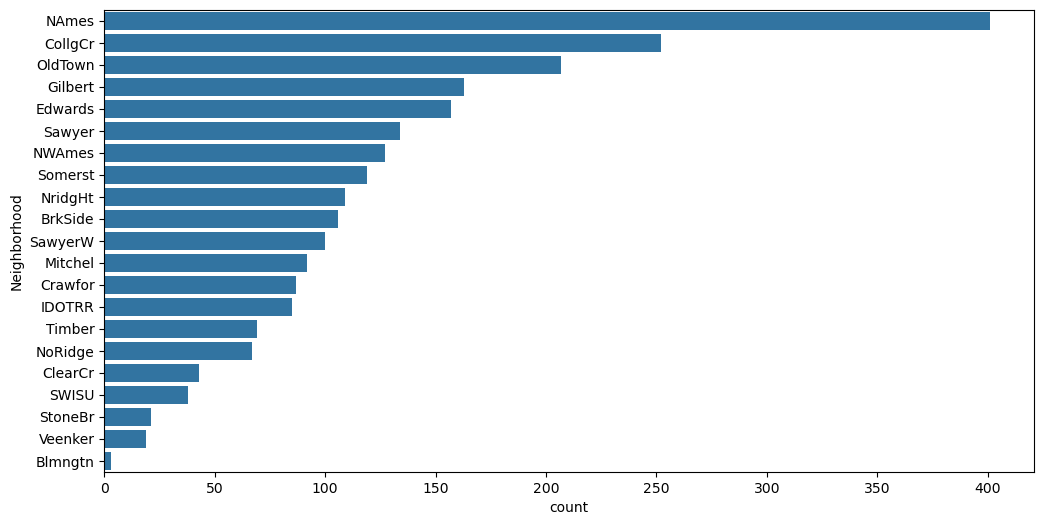

In [199]:
#Initial Eda
#Neighborhood
plt.figure(figsize = (12,6))
sns.countplot(y = df_sample["Neighborhood"], order=df_sample['Neighborhood'].value_counts().index)
plt.show()

/var/folders/6l/1tlwwbfx4jncfj1xhbt9dwdw0000gn/T/ipykernel_15996/593335764.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


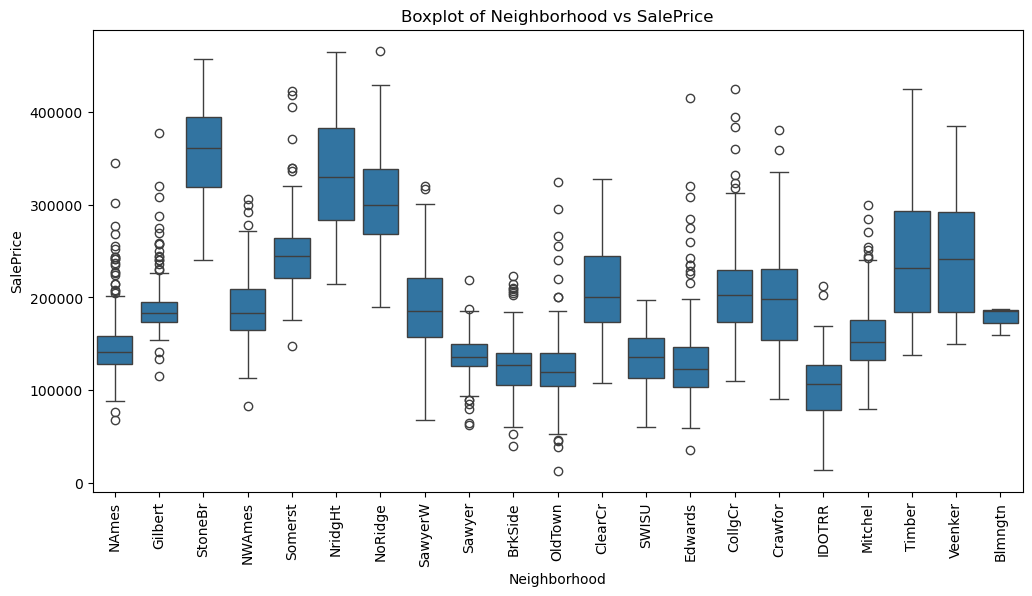

In [205]:
plt.figure(figsize = (12,6))
ax = sns.boxplot(x = df_sample["Neighborhood"], y = df_sample["SalePrice"])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title("Boxplot of Neighborhood vs SalePrice")
plt.show()

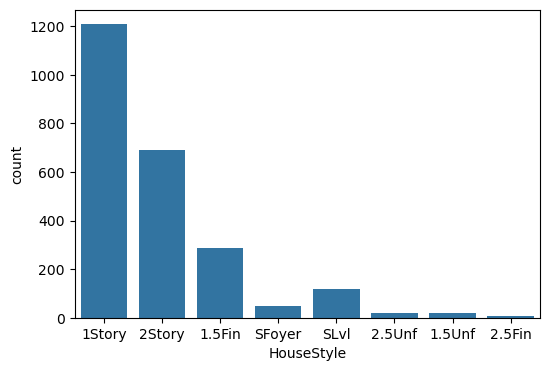

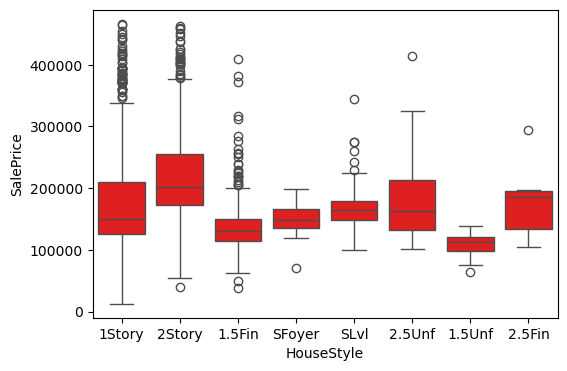

In [201]:
#HouseStyle
plt.figure(figsize=(6,4))
sns.countplot(x=df_sample["HouseStyle"])
plt.show()

plt.figure(figsize = (6,4))
sns.boxplot(x = df_sample["HouseStyle"], y = df_sample["SalePrice"], color = "red")
plt.show()

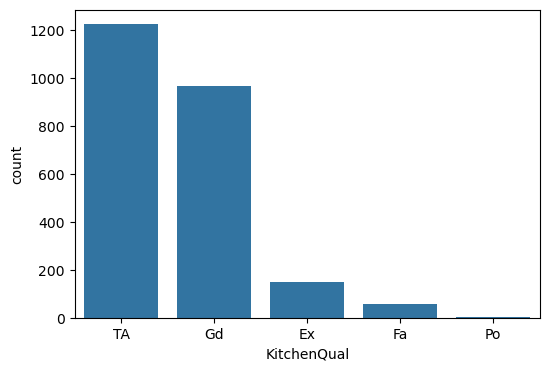

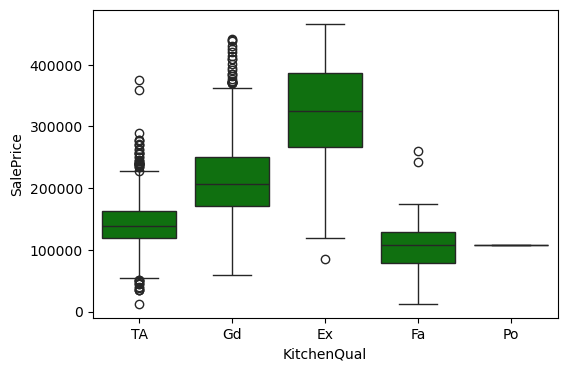

In [202]:
#Kitchen Qual
plt.figure(figsize=(6,4))
sns.countplot(x=df_sample["KitchenQual"])
plt.show()

plt.figure(figsize = (6,4))
sns.boxplot(x = df_sample["KitchenQual"], y = df_sample["SalePrice"], color = "green")
plt.show()

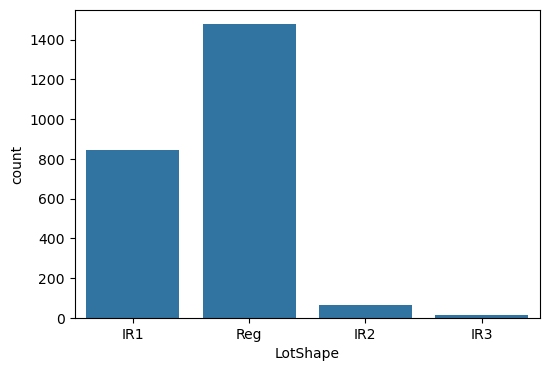

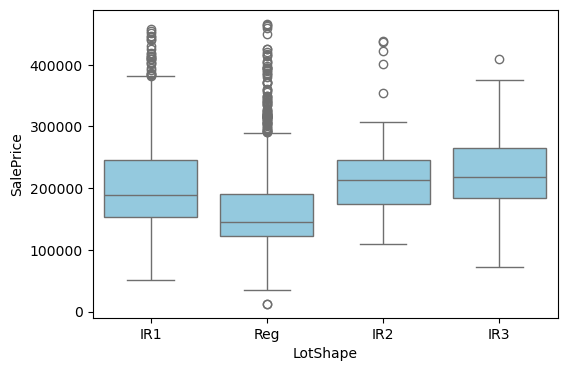

In [203]:
#Lot Shape
plt.figure(figsize=(6,4))
sns.countplot(x=df_sample["LotShape"])
plt.show()

plt.figure(figsize = (6,4))
sns.boxplot(x = df_sample["LotShape"], y = df_sample["SalePrice"], color = "skyblue")
plt.show()

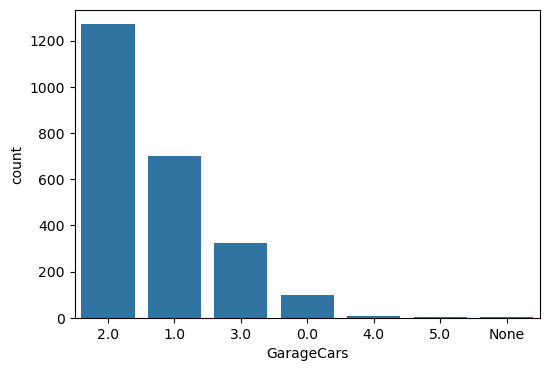

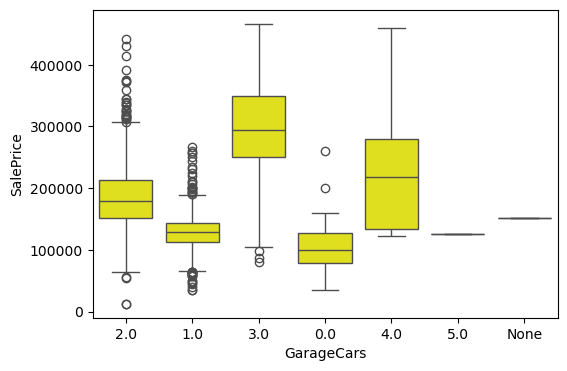

In [204]:
#GarageCars
plt.figure(figsize=(6,4))
sns.countplot(x=df_sample["GarageCars"])
plt.show()

plt.figure(figsize = (6,4))
sns.boxplot(x = df_sample["GarageCars"], y = df_sample["SalePrice"], color = "yellow")
plt.show()

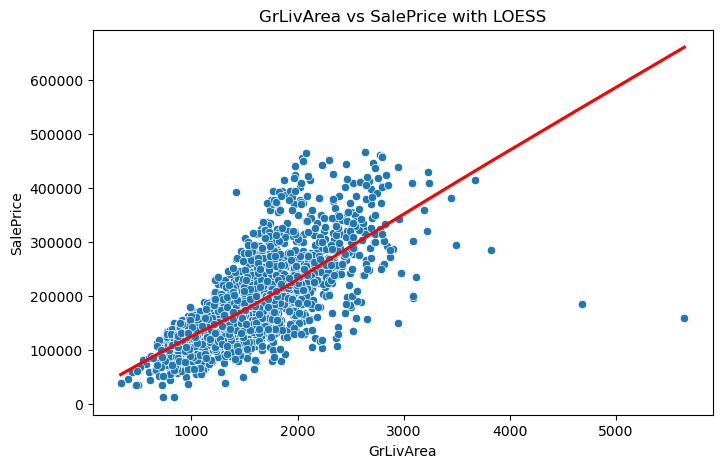

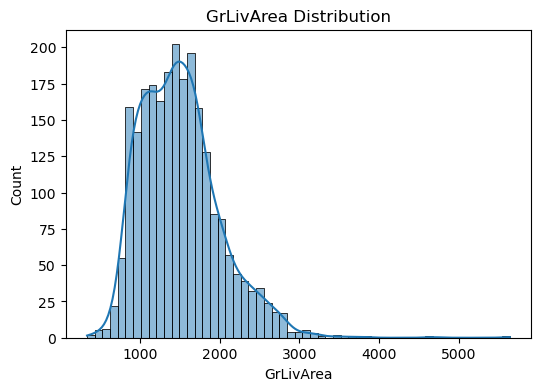

In [217]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_sample)
sns.regplot(x='GrLivArea', y='SalePrice', data=df_sample, scatter=False, lowess=True, color='red')
plt.title('GrLivArea vs SalePrice with LOESS')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(x = df_sample["GrLivArea"], kde = True)
plt.title("GrLivArea Distribution")
plt.show()

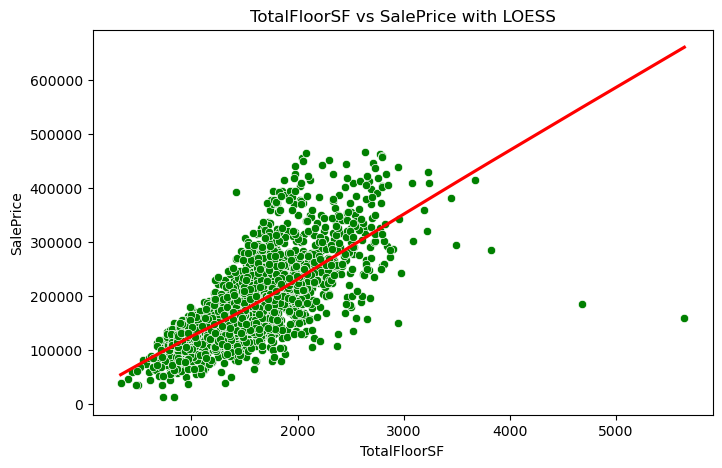

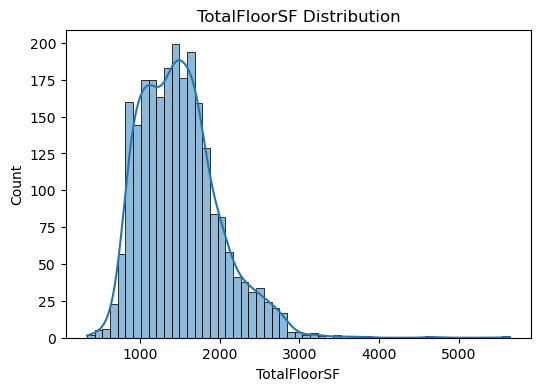

In [218]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='TotalFloorSF', y='SalePrice', data=df_sample, color='green')
sns.regplot(x='TotalFloorSF', y='SalePrice', data=df_sample, scatter=False, lowess=True, color='red')
plt.title('TotalFloorSF vs SalePrice with LOESS')
plt.xlabel('TotalFloorSF')
plt.ylabel('SalePrice')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(x = df_sample["TotalFloorSF"], kde = True)
plt.title("TotalFloorSF Distribution")
plt.show()

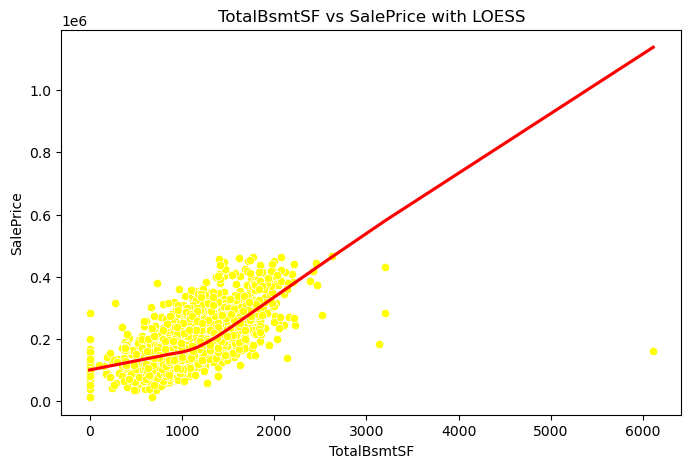

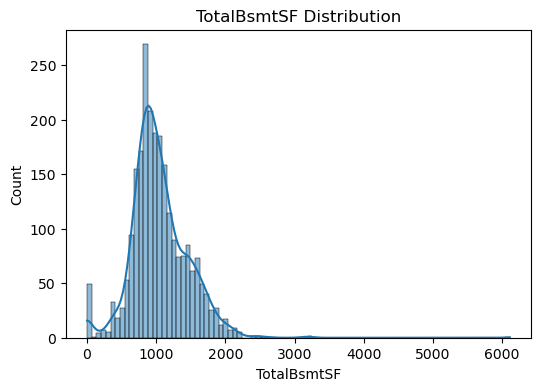

In [219]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=df_sample, color='yellow')
sns.regplot(x='TotalBsmtSF', y='SalePrice', data=df_sample, scatter=False, lowess=True, color='red')
plt.title('TotalBsmtSF vs SalePrice with LOESS')
plt.xlabel('TotalBsmtSF')
plt.ylabel('SalePrice')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(x = df_sample["TotalBsmtSF"], kde = True)
plt.title("TotalBsmtSF Distribution")
plt.show()

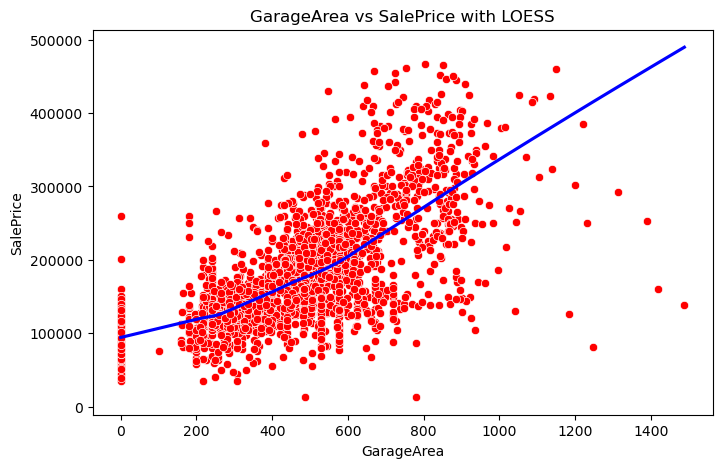

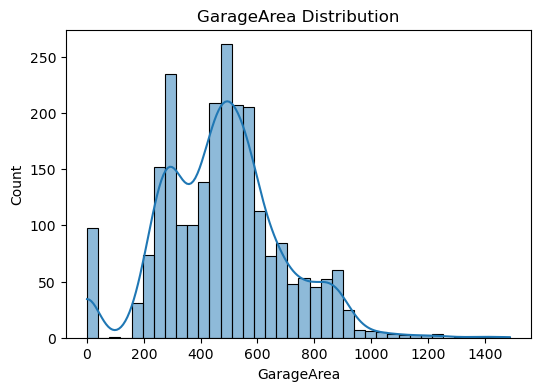

In [220]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='GarageArea', y='SalePrice', data=df_sample, color='red')
sns.regplot(x='GarageArea', y='SalePrice', data=df_sample, scatter=False, lowess=True, color='blue')
plt.title('GarageArea vs SalePrice with LOESS')
plt.xlabel('GarageArea')
plt.ylabel('SalePrice')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(x = df_sample["GarageArea"], kde = True)
plt.title("GarageArea Distribution")
plt.show()

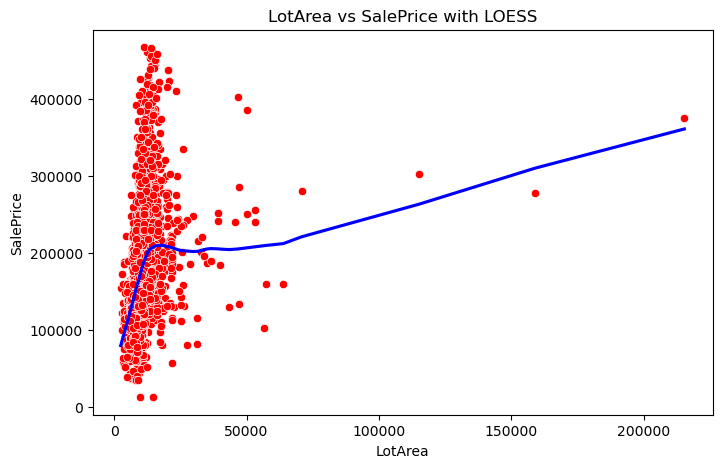

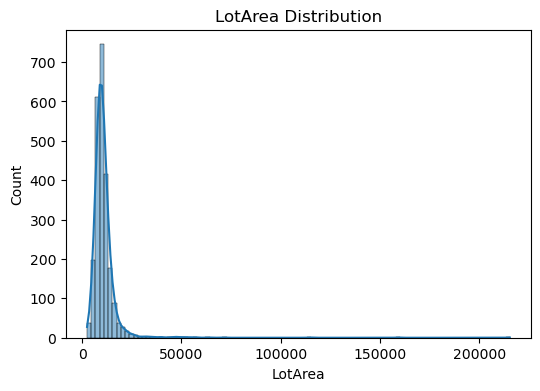

In [224]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='LotArea', y='SalePrice', data=df_sample, color='red')
sns.regplot(x='LotArea', y='SalePrice', data=df_sample, scatter=False, lowess=True, color='blue')
plt.title('LotArea vs SalePrice with LOESS')
plt.xlabel('LotArea')
plt.ylabel('SalePrice')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(x = df_sample["LotArea"], kde = True, bins = 100)
plt.title("LotArea Distribution")
plt.show()

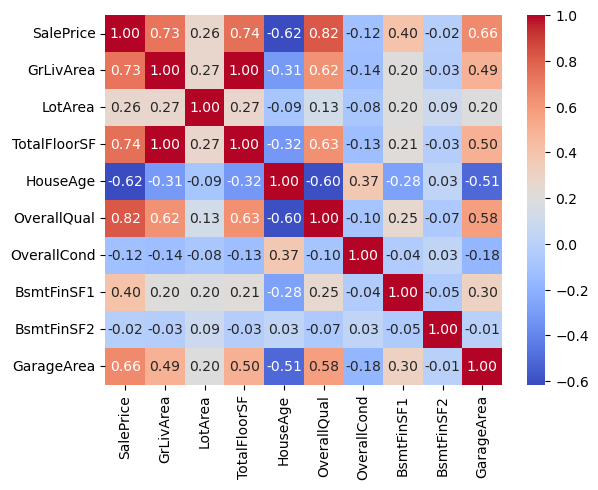

In [216]:
sns.heatmap(df_sample[num_vars].corr(), annot=True, cmap = "coolwarm", fmt=".2f")
plt.show()

In [228]:
df_sample["SalePrice_log"] = np.log(df_sample["SalePrice"])


/var/folders/6l/1tlwwbfx4jncfj1xhbt9dwdw0000gn/T/ipykernel_15996/3674311117.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


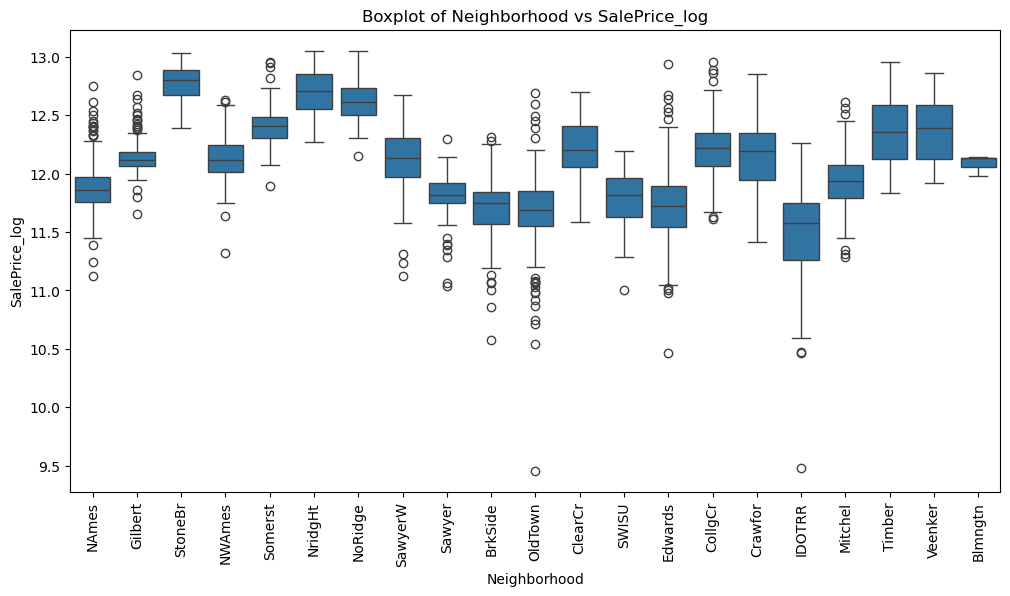

In [229]:
plt.figure(figsize = (12,6))
ax = sns.boxplot(x = df_sample["Neighborhood"], y = df_sample["SalePrice_log"])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title("Boxplot of Neighborhood vs SalePrice_log")
plt.show()

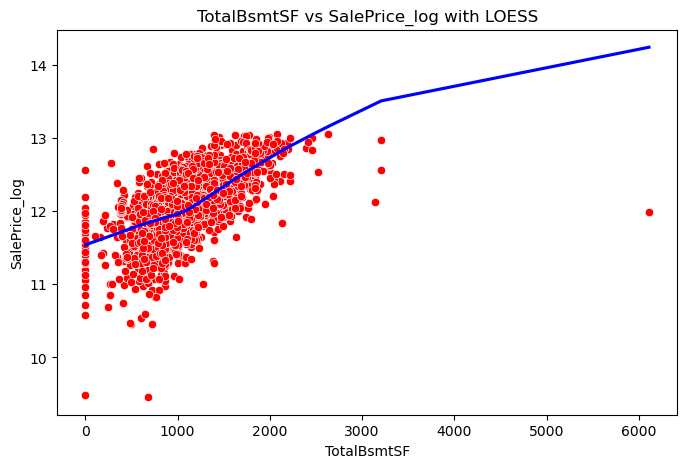

In [233]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='TotalBsmtSF', y='SalePrice_log', data=df_sample, color='red')
sns.regplot(x='TotalBsmtSF', y='SalePrice_log', data=df_sample, scatter=False, lowess=True, color='blue')
plt.title('TotalBsmtSF vs SalePrice_log with LOESS')
plt.xlabel('TotalBsmtSF')
plt.ylabel('SalePrice_log')
plt.show()

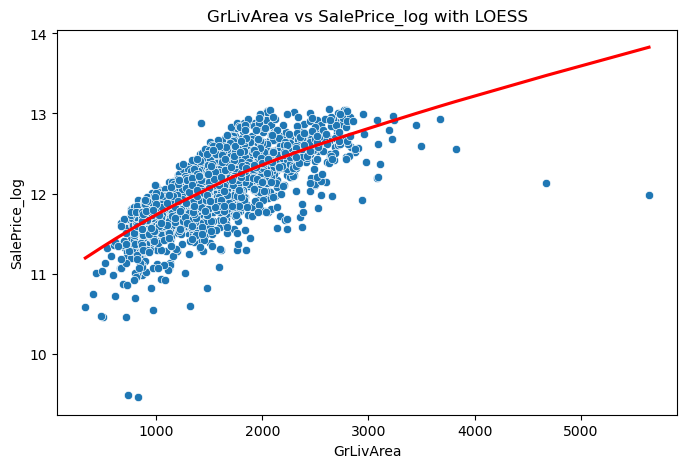

In [234]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='GrLivArea', y='SalePrice_log', data=df_sample)
sns.regplot(x='GrLivArea', y='SalePrice_log', data=df_sample, scatter=False, lowess=True, color='red')
plt.title('GrLivArea vs SalePrice_log with LOESS')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice_log')
plt.show()